In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression ,Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')


In [2]:
data = pd.read_csv('car_data.csv')
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
#WHAT are the feature of this dataset (independent variable) and what is the target variable (dependent variable )
data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [4]:
data.shape

(301, 9)

In [5]:
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [6]:
fuel_statistics = data['Fuel_Type'].value_counts()
fuel_statistics

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

In [7]:
fuel_statistics =data.groupby('Fuel_Type')['Selling_Price'].agg(['count', 
    'mean', 
    'median', 
    'std', 
    'min', 
    'max'
]).round(2)
fuel_statistics

,count,mean,median,std,min,max
Fuel_Type,,,,,,
CNG,2,3.10,3.10,0.21,2.95,3.25
Diesel,60,10.28,7.75,7.19,3.10,35.00
Petrol,239,3.26,2.65,3.14,0.10,19.75


In [8]:
numeric_features = data.select_dtypes(include=[np.number])
numeric_features.corr()
#correlation means how strong the relationship between two variable 
#here the correlation means does the More x is related to more Y,anyway because we have categorical and numerical features so we are going to use ANOVA


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Year,1.000000,0.236141,-0.047584,-0.524342,-0.182104
Selling_Price,0.236141,1.000000,0.878983,0.029187,-0.088344
Present_Price,-0.047584,0.878983,1.000000,0.203647,0.008057
Kms_Driven,-0.524342,0.029187,0.203647,1.000000,0.089216
Owner,-0.182104,-0.088344,0.008057,0.089216,1.000000


In [9]:
from scipy import stats


Text(0, 0.5, 'Selling Price (Lakhs)')

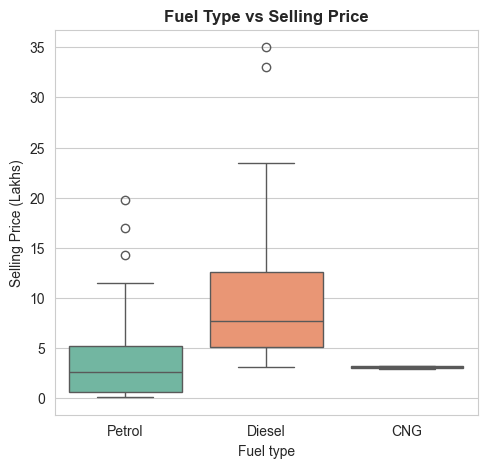

In [10]:
#Fuel type vs Selling Price
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=data, palette='Set2')
plt.title('Fuel Type vs Selling Price', fontweight='bold')
plt.xlabel('Fuel type')
plt.ylabel('Selling Price (Lakhs)')

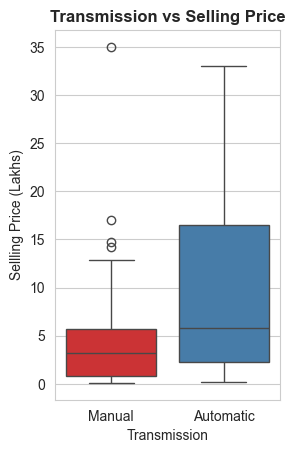

In [11]:
#Transmission vs Selling Price
plt.subplot(1,2,2)
sns.boxplot(x='Transmission', y='Selling_Price',data=data, palette='Set1')
plt.title('Transmission vs Selling Price', fontweight='bold')
plt.xlabel('Transmission')
plt.ylabel('Sellling Price (Lakhs)')
plt.show()

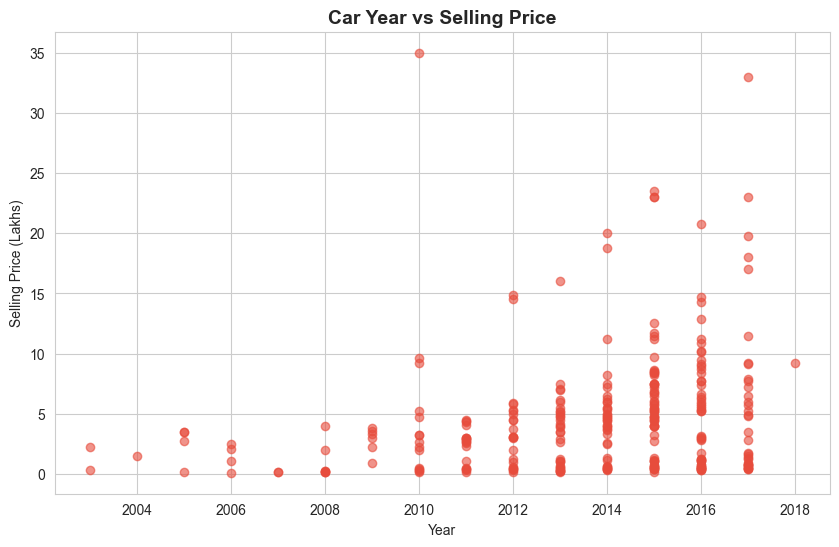

In [12]:
#Year vs Selling Price
plt.figure(figsize=(10,6))
plt.scatter(data['Year'],data['Selling_Price'], alpha=0.6, c='#e74c3c')
plt.title('Car Year vs Selling Price', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

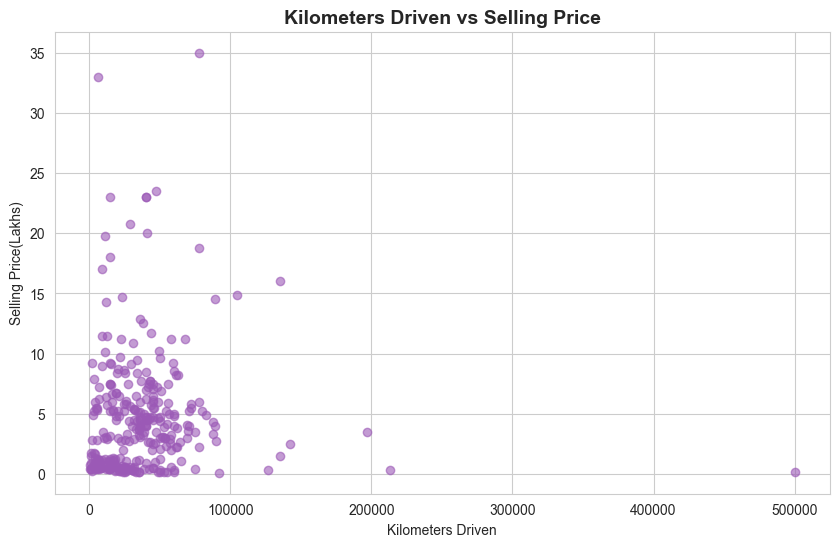

In [13]:
#Kms driven vs Selling Price

plt.figure(figsize=(10,6))
plt.scatter(data['Kms_Driven'], data['Selling_Price'], alpha=0.6, c='#9b59b6')
plt.title('Kilometers Driven vs Selling Price',fontsize=14, fontweight='bold')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price(Lakhs)')
plt.show()

In [17]:
groups = [data[data['Fuel_Type'] == fuel]['Selling_Price'] for fuel in data['Fuel_Type'].unique()]


In [18]:
# Now run ANOVA with your groups
f_stat, p_value = stats.f_oneway(*groups)

# Print results
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 65.4149
P-value: 0.0000


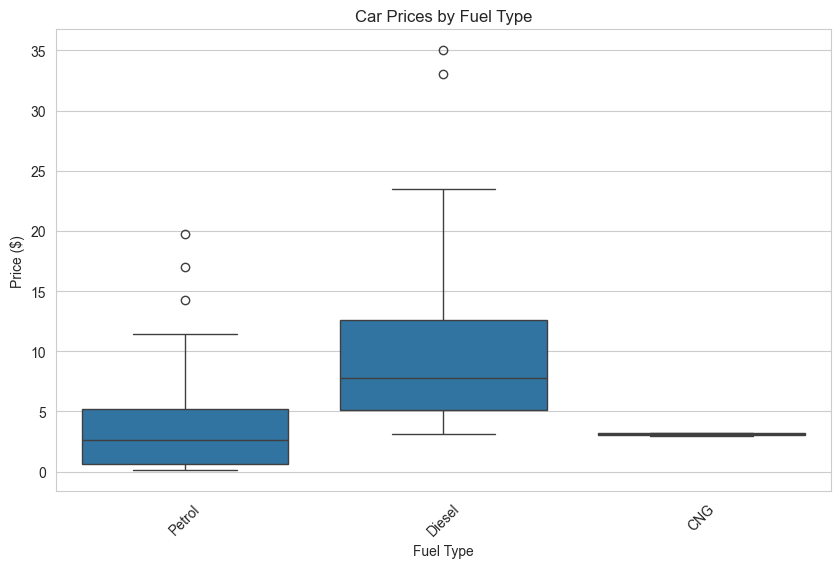

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=data)
plt.title('Car Prices by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
groupcarname=[data['Fuel_Type'] == fuel]['Selling_Price'] for fuel in data['Fuel_Type'].unique()]
